## Построение Embeddings для токенов на примере Word2Vec

In [ ]:
from pathlib import Path

import pymorphy2
import re
from gensim.utils import simple_preprocess

from gensim.models import Word2Vec

import nltk

### Подготовка данных

Приведение слов к начальной форме, токенизация (по словам)

In [2]:
morph = pymorphy2.MorphAnalyzer()

def tokenize_ru(text):
    words = simple_preprocess(text, deacc=True)  # убирает пунктуацию
    lemmas = []
    for w in words:
        p = morph.parse(w)
        if p:
            lemmas.append(p[0].normal_form)
    return lemmas

In [3]:
text = 'Это тестовое предложение, с помощью которого мы проверим токенизацию!'

print(tokenize_ru(text))

['это', 'тестовый', 'предложение', 'помощь', 'который', 'мы', 'проверить', 'токенизация']


In [ ]:
# токенизация
from corus import load_lenta

input_path = "../data/lenta-ru-news.csv.gz" # можно скачать здесь: https://github.com/yutkin/Lenta.Ru-News-Dataset
output_path = "../data/lenta_tok.txt"

with open(output_path, 'w', encoding='utf-8') as f:
    for record in load_lenta(input_path):
        tokens = tokenize_ru(record.text) 
        if len(tokens) >= 3:
            f.write(' '.join(tokens) + '\n')

### Обучение Word2Vec

In [ ]:
from gensim.models.word2vec import LineSentence

model = Word2Vec(
    sentences=LineSentence(output_path),
    vector_size=128,
    window=4,
    min_count=5,
    workers=2,
    epochs=10,
    sg=1,
    negative=5,
    max_final_vocab=40000 
)

model.save("../models/lenta.model")

### Результаты обучения

In [4]:
model = Word2Vec.load("../models/lenta.model")

In [5]:
# 1. Похожие слова
words = model.wv.most_similar("гергиев", topn=5)

for i in range(len(words)):
    print(f'{i}) {words[i][0]} ({round(words[i][1], 3)})')

0) дирижёр (0.778)
1) башмет (0.763)
2) оркестр (0.718)
3) симфонический (0.703)
4) спиваков (0.686)


In [32]:
words = model.wv.most_similar("машина", topn=5)

for i in range(len(words)):
    print(f'{i}) {words[i][0]} ({round(words[i][1], 3)})')

0) автомобиль (0.879)
1) автомашина (0.824)
2) джип (0.793)
3) уаз (0.75)
4) микроавтобус (0.747)


In [35]:
words = model.wv.most_similar("ильич", topn=5)

for i in range(len(words)):
    print(f'{i}) {words[i][0]} ({round(words[i][1], 3)})')

0) ленин (0.722)
1) маяковский (0.569)
2) достоевский (0.56)
3) сталин (0.557)
4) вождь (0.554)


In [ ]:
# 2. Аналогии (проверка линейных свойств)
print(model.wv.most_similar(positive=["италия", "москва"], negative=["россия"], topn=3)) # Москва - Россия + Италия = Рим

[('рим', 0.734878420829773), ('мадрид', 0.7005112171173096), ('палермо', 0.6866071224212646)]


In [ ]:
print(model.wv.most_similar(positive=["доллар", "россия"], negative=["сша"], topn=3)) # Доллар - США + Россия = Рубль

[('рублей', 0.7726427316665649), ('гривна', 0.6079665422439575), ('евро', 0.5958508849143982)]


In [ ]:
print(model.wv.most_similar(positive=["муж", "женщина"], negative=["мужчина"], topn=3)) # муж - мужчина + женщина = жена

[('жена', 0.829801082611084), ('дочь', 0.8250786662101746), ('супруг', 0.799607515335083)]


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from gensim.models import KeyedVectors

def plot_word_embeddings(
    model_path,
    highlight_words,
    method='tsne',           # 'tsne' или 'pca'
    max_background=5000,     # сколько случайных слов показать серым (для скорости)
    perplexity=30,           # только для t-SNE
    random_state=42,
    figsize=(12, 10),
    highlight_color='red',
    background_alpha=0.3,
    label_fontsize=9,
    picture_path='D:/Сергей/Desktop/Толик/ИРИТ-РТФ/5 курс/Мат. методы/default.png'
):
    """
    Визуализация Word2Vec эмбеддингов.
    
    Parameters:
    - model_path: путь к .model или .wordvectors
    - highlight_words: список слов для выделения
    - method: 'tsne' или 'pca'
    - max_background: лимит фоновых точек (чтобы не тормозило)
    """
    
    # 1. Загрузка модели
    print("📦 Загрузка модели...")
    if model_path.endswith('.wordvectors'):
        wv = KeyedVectors.load(model_path, mmap='r')
    else:
        # Если .model — можно загрузить целиком или извлечь wv
        from gensim.models import Word2Vec
        model = Word2Vec.load(model_path)
        wv = model.wv
    
    # 2. Фильтрация: оставляем только слова, которые есть в модели
    valid_highlight = [w for w in highlight_words if w in wv]
    missing = set(highlight_words) - set(valid_highlight)
    if missing:
        print(f"⚠️ Не найдено в словаре: {missing}")
    
    if not valid_highlight:
        print("❌ Нет валидных слов для выделения. Выход.")
        return
    
    # 3. Подготовка данных
    all_words = list(wv.index_to_key)
    
    # Случайная выборка фоновых слов (чтобы не рисовать 100K точек)
    if len(all_words) > max_background:
        rng = np.random.default_rng(random_state)
        background_words = rng.choice(
            [w for w in all_words if w not in valid_highlight],
            size=max_background,
            replace=False
        ).tolist()
    else:
        background_words = [w for w in all_words if w not in valid_highlight]
    
    # Объединяем: фон + выделенные
    plot_words = background_words + valid_highlight
    vectors = np.array([wv[w] for w in plot_words])
    
    print(f"📊 Визуализируем {len(plot_words)} векторов размерности {vectors.shape[1]}")
    
    # 4. Снижение размерности
    print(f"🔄 Применяем {method.upper()}...")
    if method == 'pca':
        reducer = PCA(n_components=2, random_state=random_state)
    elif method == 'tsne':
        reducer = TSNE(
            n_components=2,
            perplexity=min(perplexity, len(plot_words) - 1),
            random_state=random_state,
            max_iter=1000,
            learning_rate='auto',
            init='pca',
            verbose=0
        )
    else:
        raise ValueError("method должен быть 'tsne' или 'pca'")
    
    coords = reducer.fit_transform(vectors)
    
    # 5. Разделяем координаты на фон и выделенные
    bg_coords = coords[:len(background_words)]
    hl_coords = coords[len(background_words):]
    
    # 6. Построение графика
    print("🎨 Рисуем...")
    plt.figure(figsize=figsize)
    
    # Фон: серые полупрозрачные точки
    plt.scatter(
        bg_coords[:, 0], bg_coords[:, 1],
        c='gray', s=10, alpha=background_alpha,
        label='Другие токены', zorder=1
    )
    
    # Выделенные слова: цветные точки + подписи
    colors = plt.cm.tab10(np.linspace(0, 1, len(valid_highlight)))
    for i, (word, (x, y)) in enumerate(zip(valid_highlight, hl_coords)):
        plt.scatter(x, y, c='red', s=50, zorder=3, edgecolors='black')
        plt.text(
            x, y, f' {word}',
            fontsize=label_fontsize,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
            zorder=4
        )
    
    # Оформление
    plt.title(f'Word2Vec Embeddings ({method.upper()})', fontsize=14, pad=20)
    plt.xlabel('Component 1', fontsize=10)
    plt.ylabel('Component 2', fontsize=10)
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    # Сохранение + показ
    output_path = picture_path
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✅ График сохранён: {output_path}")
    plt.show()
    
    # return coords, plot_words  # на случай, если нужно дальше анализировать

📦 Загрузка модели...
📊 Визуализируем 4008 векторов размерности 128
🔄 Применяем TSNE...
🎨 Рисуем...
✅ График сохранён: ../img/composers.png


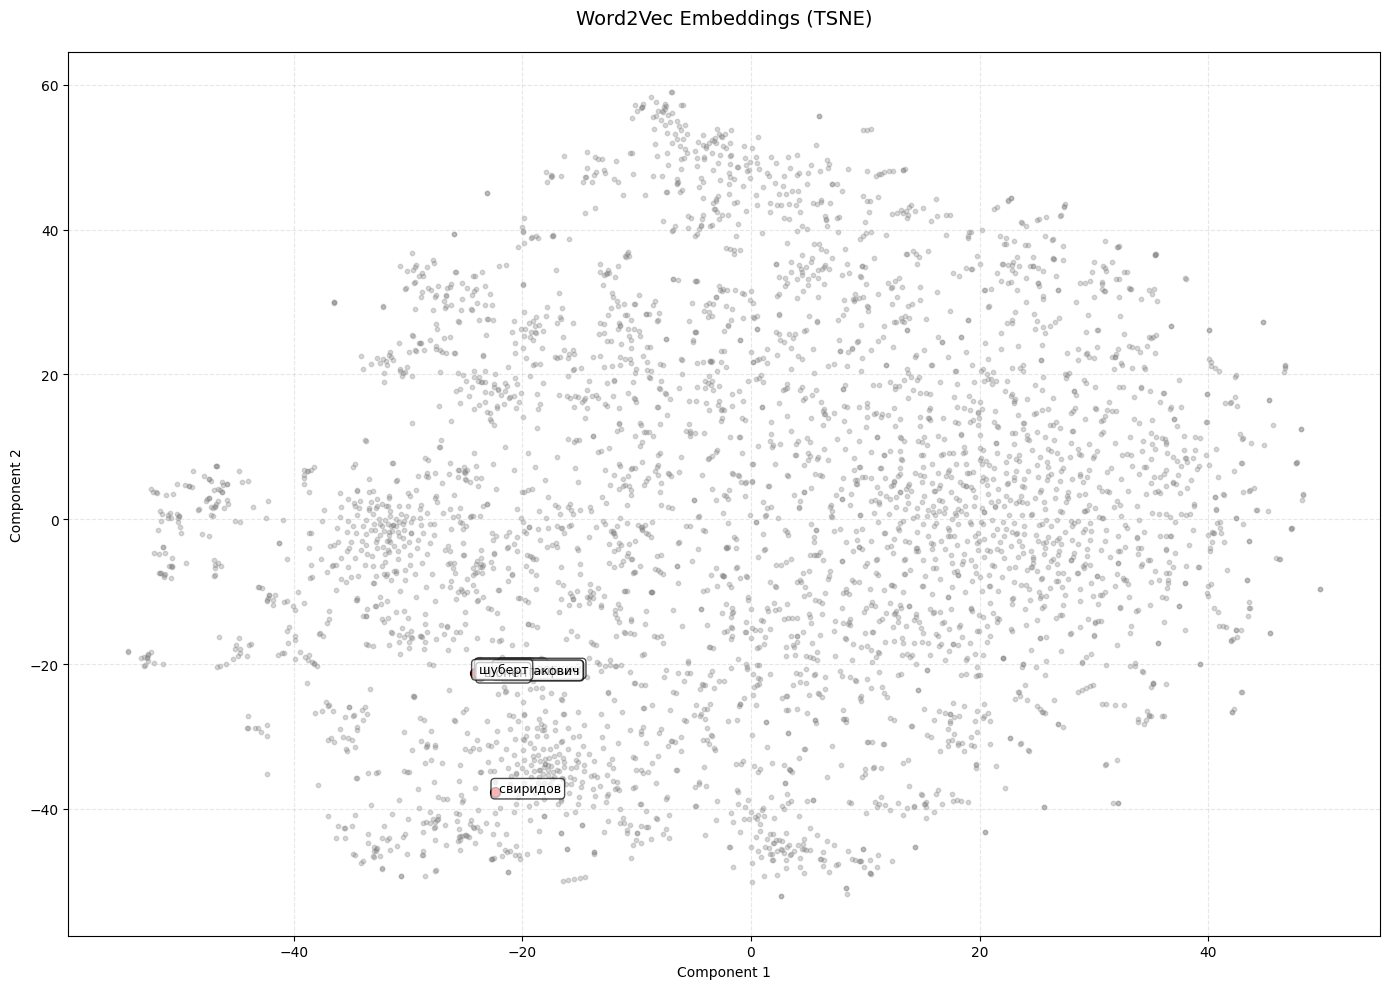

In [38]:
my_words = ['бетховен', 'моцарт', 'чаиковский', 'прокофьев', 'шостакович', 'свиридов', 'шопен', 'шуберт']

# Запуск визуализации
plot_word_embeddings(
    model_path='../models/lenta.model',  # 
    highlight_words=my_words,
    method='tsne',          
    max_background=4000,    # меньше = быстрее, но менее репрезентативно
    perplexity=30,
    figsize=(14, 10),
    picture_path = '../img/composers.png'
)